In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder,LabelEncoder

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,mean_absolute_error,mean_squared_error,f1_score
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
import joblib

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

In [8]:
df=pd.read_csv(r"C:\Users\Dell\Desktop\Churn_Modelling.csv")

In [9]:
df.drop(columns=['Surname',"CustomerId","RowNumber"],inplace=True)

In [10]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [12]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\n{col} value counts:\n", df[col].value_counts())


Geography value counts:
 Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender value counts:
 Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [13]:
num_cols = df.select_dtypes(include=np.number).columns

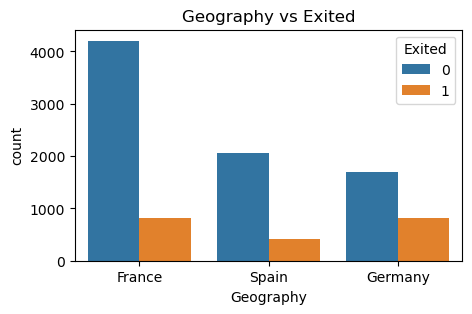

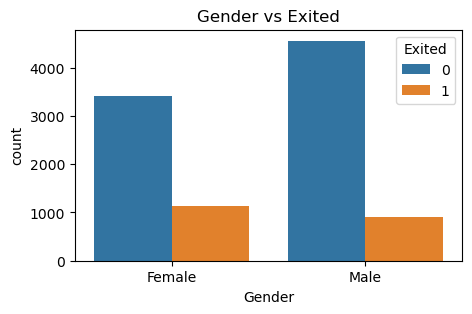

In [14]:
for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, hue='Exited', data=df)
    plt.title(f'{col} vs Exited')
    plt.show()

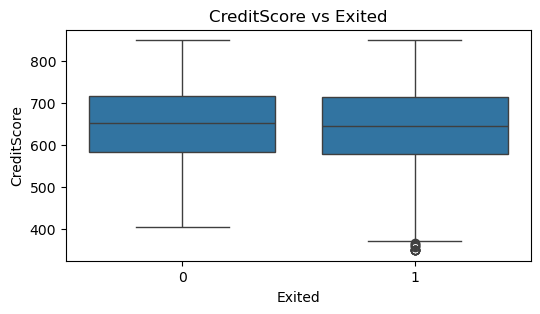

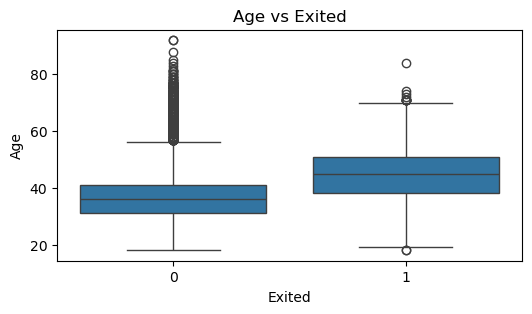

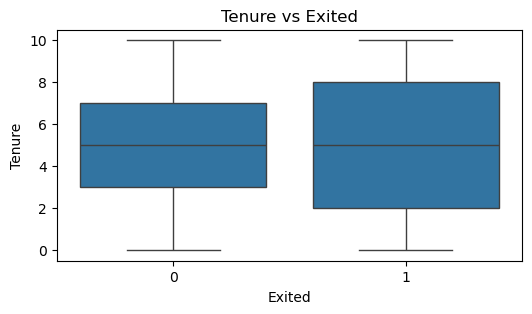

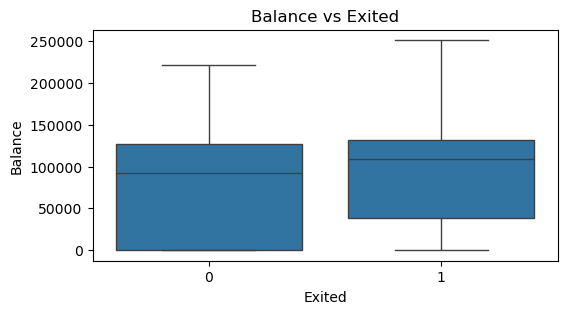

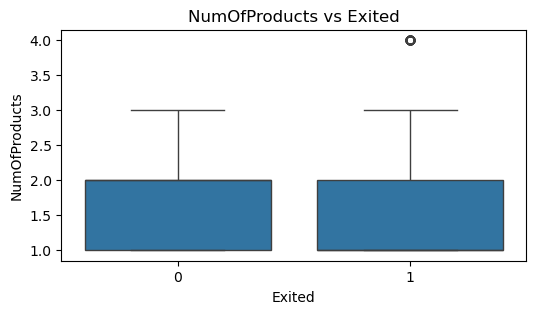

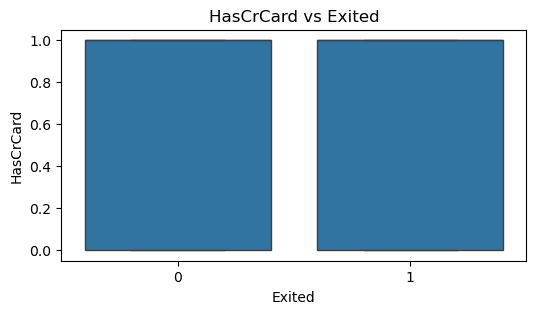

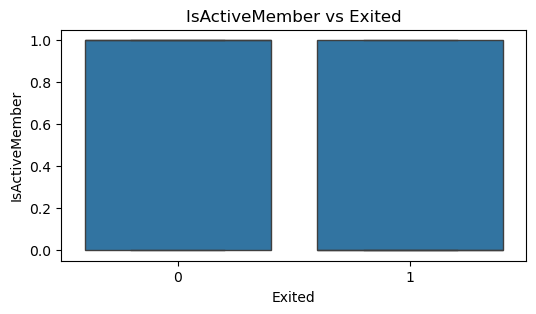

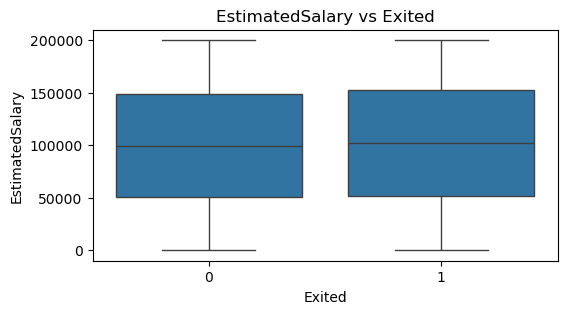

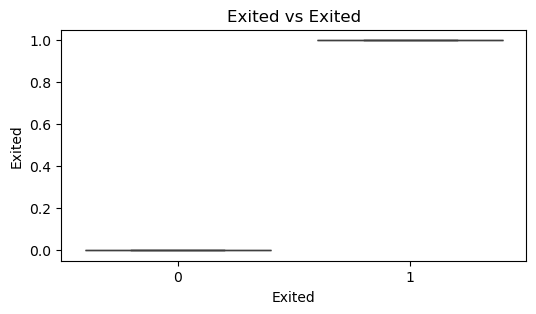

In [15]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f'{col} vs Exited')
    plt.show()

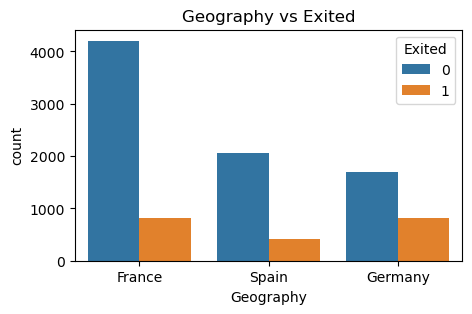

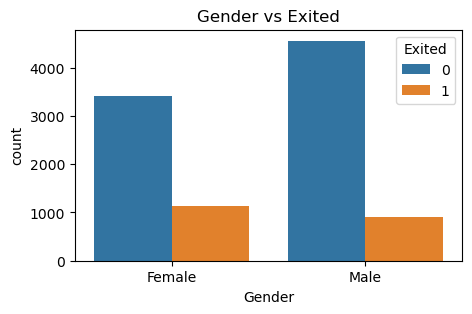

In [16]:
for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, hue='Exited', data=df)
    plt.title(f'{col} vs Exited')
    plt.show()


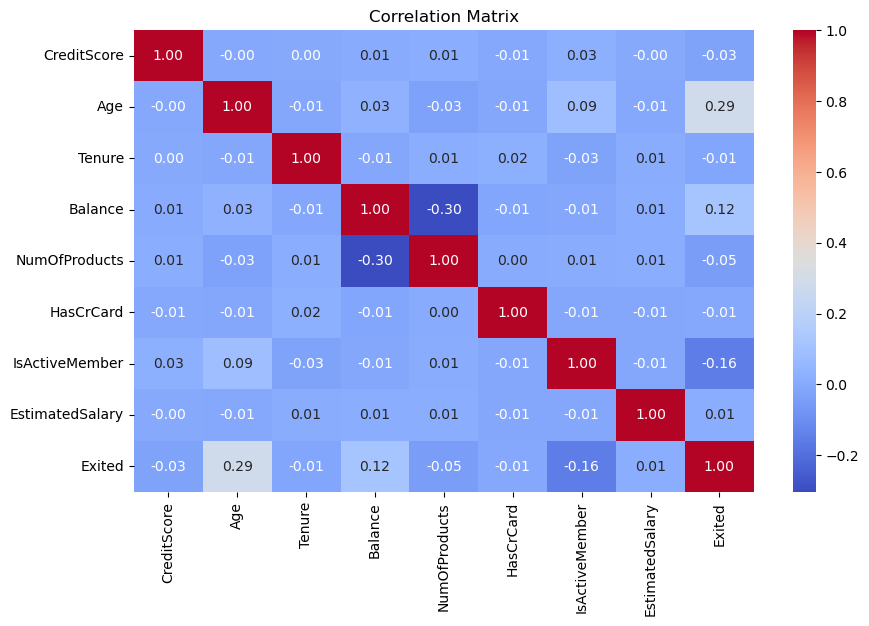

In [17]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig(" corr marix")
plt.show()

In [18]:
x=df.iloc[:,0:-1]  #df.drop(columns=[purchased])

In [19]:
y=df.iloc[:,-1] 

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y)

In [21]:
categorical_cols = ["Geography", "Gender"]
numeric_cols = x_train.columns.difference(categorical_cols)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(sparse_output=True,drop="first"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

In [22]:
rf = RandomForestClassifier(n_estimators=300,max_depth=8,min_samples_leaf=50,min_samples_split=100,max_features='sqrt', class_weight='balanced',random_state=42, n_jobs=-1)

In [23]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model",rf)
])

In [24]:

pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  Index(['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'HasCrCard',
       'IsActiveMember', 'NumOfProducts', 'Tenure'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=50,
                                        min_samples_split=100, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [25]:
y_pred = pipe.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 80.63333333333334
Confusion Matrix:
 [[1955  434]
 [ 147  464]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      2389
           1       0.52      0.76      0.61       611

    accuracy                           0.81      3000
   macro avg       0.72      0.79      0.74      3000
weighted avg       0.85      0.81      0.82      3000



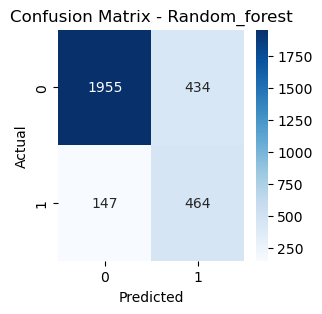

In [26]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {'Random_forest'}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("confusion")
plt.show()



In [27]:
scores = cross_val_score(
    pipe, x_train, y_train, cv=5, scoring="roc_auc"
)

print("Mean ROC-AUC:", scores.mean())

Mean ROC-AUC: 0.8429361982589965


In [28]:
f1_score(y_test,y_pred)*100

61.49768058316766

In [29]:
accuracy_score(y_test,y_pred)*100

80.63333333333334

In [30]:
print("mae",mean_absolute_error(y_test,y_pred))

mae 0.19366666666666665


In [31]:
print("mse",mean_squared_error(y_test,y_pred))

mse 0.19366666666666665


In [32]:
confusion_matrix(y_test,y_pred)

array([[1955,  434],
       [ 147,  464]], dtype=int64)

In [33]:
y_pred_tr= pipe.predict(x_train)

print("Accuracy:", accuracy_score(y_train, y_pred_tr) * 100)
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_tr))
print(classification_report(y_train, y_pred_tr))

Accuracy: 80.54285714285714
Confusion Matrix:
 [[4544 1030]
 [ 332 1094]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5574
           1       0.52      0.77      0.62      1426

    accuracy                           0.81      7000
   macro avg       0.72      0.79      0.74      7000
weighted avg       0.85      0.81      0.82      7000



In [34]:
joblib.dump(pipe, "churn_model.joblib")
print("Model saved as churn_model.joblib")

Model saved as churn_model.joblib


In [35]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("churn_model.joblib")

st.title("Customer Churn Prediction")

st.write("Enter customer details:")

credit_score = st.number_input("Credit Score", 300, 900, 650)
geography = st.selectbox("Geography", ["India","France", "Germany", "Spain","US","other"])
gender = st.selectbox("Gender", ["Male", "Female"])
age = st.number_input("Age", 18, 100, 40)
tenure = st.number_input("Tenure", 0, 10, 3)
balance = st.number_input("Balance", 0.0, 300000.0, 50000.0)
num_products = st.number_input("Number of Products", 1, 4, 1)
has_card = st.selectbox("Has Credit Card", [0, 1])
is_active = st.selectbox("Is Active Member", [0, 1])
salary = st.number_input("Estimated Salary", 0.0, 300000.0, 60000.0)

if st.button("Predict Churn"):
    input_df = pd.DataFrame([{
        "CreditScore": credit_score,
        "Geography": geography,
        "Gender": gender,
        "Age": age,
        "Tenure": tenure,
        "Balance": balance,
        "NumOfProducts": num_products,
        "HasCrCard": has_card,
        "IsActiveMember": is_active,
        "EstimatedSalary": salary
    }])

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.error(f"Customer WILL churn ⚠️ (Probability: {probability:.2f})")
    else:
        st.success(f"Customer will NOT churn ✅ (Probability: {probability:.2f})")


2026-05-17 11:47:47.035 
  command:

    streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-17 11:47:47.035 Session state does not function when running a script without `streamlit run`


In [36]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model",ada)
])

NameError: name 'ada' is not defined

In [ ]:
pipe.fit(x_train, y_train)

In [ ]:
ada = AdaBoostClassifier(n_estimators=200,learning_rate=0.05,random_state=42)

In [ ]:
y_pred = pipe.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {'Adaboost'}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("confusion")
plt.show()

In [38]:
xgb = XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,scale_pos_weight=10, random_state=42,eval_metric="logloss")

In [39]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model",xgb)
])

In [45]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  Index(['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'HasCrCard',
       'IsActiveMember', 'NumOfProducts', 'Tenure'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsampl...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [44]:
y_pred = pipe.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 72.73333333333333
Confusion Matrix:
 [[1660  729]
 [  89  522]]
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      2389
           1       0.42      0.85      0.56       611

    accuracy                           0.73      3000
   macro avg       0.68      0.77      0.68      3000
weighted avg       0.84      0.73      0.75      3000



In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {'Xgboost'}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("confusion")
plt.show()